# Analisis exploratorio de datos

## Librerias

In [1]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

## Analisis Inicial

se realiza un conteo por extension de los archivos 

In [3]:
import os
from collections import defaultdict

base_path = r"C:\Users\Hp\Documents\Deep learning\Entregable1\docs"

stats = defaultdict(int)

for root, dirs, files in os.walk(base_path):
    for f in files:
        ext = os.path.splitext(f)[1].lower()
        stats[ext] += 1

print("Conteo por extensión:")
for k,v in sorted(stats.items()):
    print(f"{k}: {v}")

Conteo por extensión:
.bib: 1
.csv: 1
.ipynb: 1
.jpeg: 5433
.jpg: 56361
.json: 1
.md: 2
.png: 84336
.txt: 7
.yml: 2


se cuentan los archivos que contiene cada carpeta de rover

In [4]:
def count_files(path):
    total = 0
    for root, dirs, files in os.walk(path):
        total += len(files)
    return total

missions = ["m2020", "mer", "msl"]

for m in missions:
    path = os.path.join(base_path, m)
    print(f"\n{m.upper()} total files: {count_files(path)}")


M2020 total files: 30401

MER total files: 26185

MSL total files: 89550


Ahora se verifican el numero de imagenes y labels de cada rover individualmente

In [5]:
import os

base_path = r"C:\Users\Hp\Documents\Deep learning\Entregable1\docs"

msl_ncam_images = os.path.join(base_path, "msl", "ncam", "images", "edr")
msl_ncam_labels = os.path.join(base_path, "msl", "ncam", "labels", "train")

msl_images = {os.path.splitext(f)[0] for f in os.listdir(msl_ncam_images) if f.lower().endswith(".jpg")}
msl_labels = {os.path.splitext(f)[0] for f in os.listdir(msl_ncam_labels) if f.lower().endswith(".png")}

print("Total images:", len(msl_images))
print("Total labels:", len(msl_labels))

print("Images without label:", len(msl_images - msl_labels))
print("Labels without image:", len(msl_labels - msl_images))

Total images: 18127
Total labels: 16064
Images without label: 2063
Labels without image: 0


In [6]:
mer_images = os.path.join(base_path, "mer", "images", "eff")
mer_labels = os.path.join(base_path, "mer", "labels", "train", "merged-unmasked")

MER_images = {os.path.splitext(f)[0] for f in os.listdir(mer_images) if f.lower().endswith(".jpg")}
MER_labels = {os.path.splitext(f)[0].split("_merged")[0] for f in os.listdir(mer_labels) if f.lower().endswith(".png")}

print("Total images:", len(MER_images))
print("Total labels:", len(MER_labels))

print("Images without label:", len(MER_images - MER_labels))
print("Labels without image:", len(MER_labels - MER_images))

Total images: 16300
Total labels: 8507
Images without label: 7997
Labels without image: 204


In [7]:
m2020_ncam_images = os.path.join(base_path, "m2020", "images", "ncam")
m2020_nav_labels = os.path.join(base_path, "m2020", "labels", "NAV")

m2020_images = {os.path.splitext(f)[0] for f in os.listdir(m2020_ncam_images) if f.lower().endswith((".jpg",".jpeg"))}
m2020_labels = {os.path.splitext(f)[0].split("_merged")[0] for f in os.listdir(m2020_nav_labels) if f.lower().endswith(".png")}

print("Total images:", len(m2020_images))
print("Total labels:", len(m2020_labels))

print("Images without label:", len(m2020_images - m2020_labels))
print("Labels without image:", len(m2020_labels - m2020_images))

Total images: 4286
Total labels: 3827
Images without label: 1931
Labels without image: 1472


Se realiza un grafico de barras para visualizar de mejor manera la distribucion de imagenes

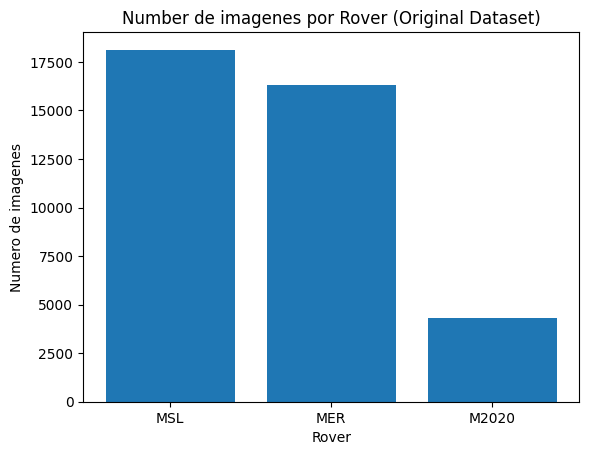

In [8]:
rovers = ["MSL", "MER", "M2020"]
image_counts = [
    len(msl_images),
    len(MER_images),
    len(m2020_images)
]

plt.figure()
plt.bar(rovers, image_counts)
plt.xlabel("Rover")
plt.ylabel("Numero de imagenes")
plt.title("Number de imagenes por Rover (Original Dataset)")
plt.show()

Podemos observar que de los 3 rovers M2020 es el que tiene menos imagenes de los 3 lo que haria que el modelo tuviera un gran desbalance a la hora del modelado

Realizamos a su vez un grafico con el ancho y el alto de las imagenes para denotar sus dimensiones 

In [9]:
widths = []
heights = []
for f in os.listdir(msl_ncam_images):
    if f.lower().endswith((".jpg", ".jpeg")):
        img_path = os.path.join(msl_ncam_images, f)
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)

print(f"Total images analyzed: {len(widths)}")

Total images analyzed: 18127


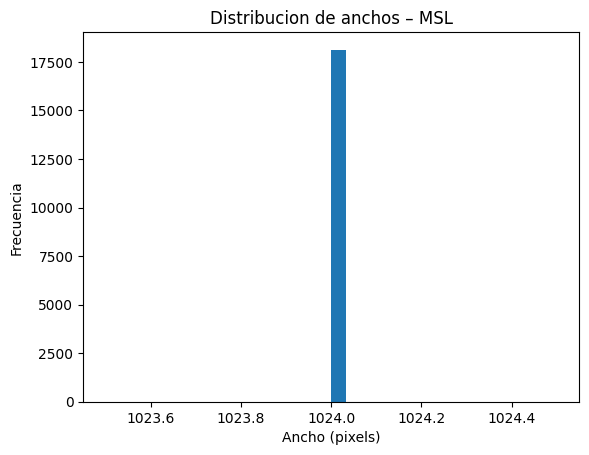

In [10]:
plt.figure()
plt.hist(widths, bins=30)
plt.xlabel("Ancho (pixels)")
plt.ylabel("Frecuencia")
plt.title("Distribucion de anchos – MSL")
plt.show()

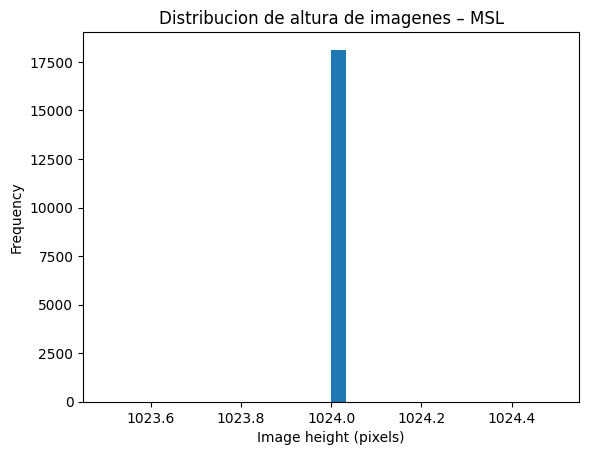

In [11]:
plt.figure()
plt.hist(heights, bins=30)
plt.xlabel("Image height (pixels)")
plt.ylabel("Frequency")
plt.title("Distribucion de altura de imagenes – MSL")
plt.show()

In [12]:
widths = []
heights = []
for f in os.listdir(mer_images):
    if f.lower().endswith((".jpg", ".jpeg")):
        img_path = os.path.join(mer_images, f)
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)

print(f"Total images analyzed: {len(widths)}")

Total images analyzed: 16300


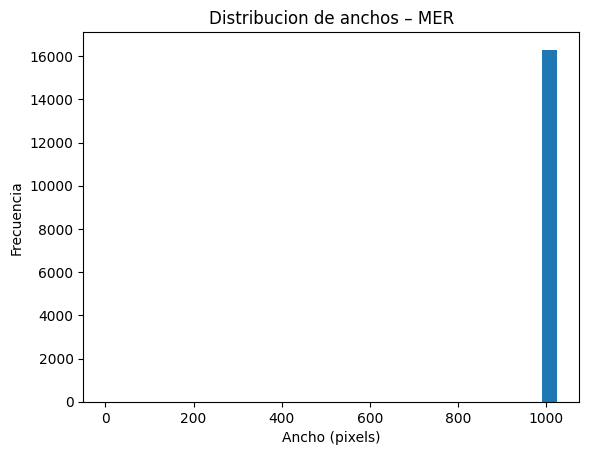

In [13]:
plt.figure()
plt.hist(widths, bins=30)
plt.xlabel("Ancho (pixels)")
plt.ylabel("Frecuencia")
plt.title("Distribucion de anchos – MER")
plt.show()

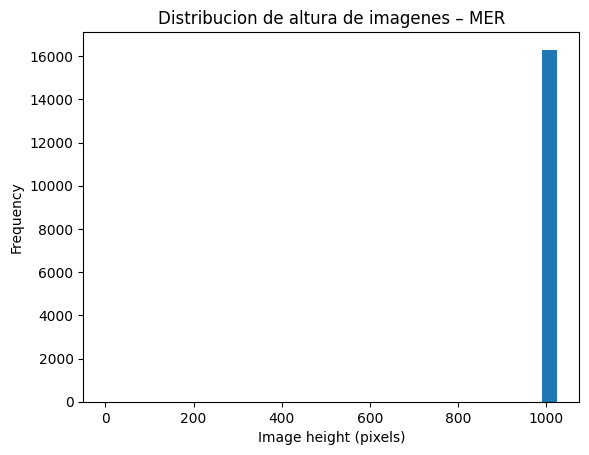

In [14]:
plt.figure()
plt.hist(heights, bins=30)
plt.xlabel("Image height (pixels)")
plt.ylabel("Frequency")
plt.title("Distribucion de altura de imagenes – MER")
plt.show()

In [15]:
widths = []
heights = []
for f in os.listdir(m2020_ncam_images):
    if f.lower().endswith((".jpg", ".jpeg")):
        img_path = os.path.join(m2020_ncam_images, f)
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)

print(f"Total images analyzed: {len(widths)}")

Total images analyzed: 4573


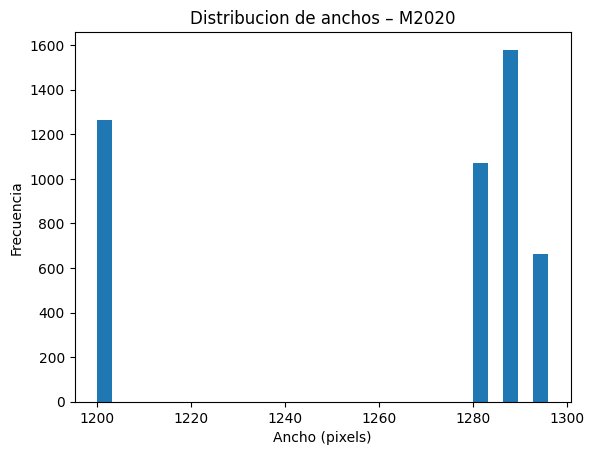

In [16]:
plt.figure()
plt.hist(widths, bins=30)
plt.xlabel("Ancho (pixels)")
plt.ylabel("Frecuencia")
plt.title("Distribucion de anchos – M2020")
plt.show()

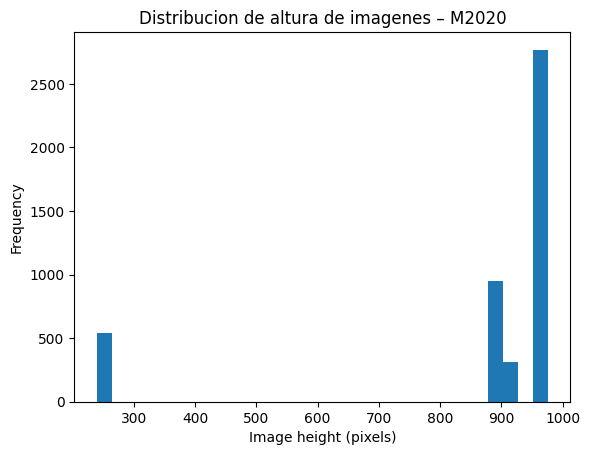

In [17]:
plt.figure()
plt.hist(heights, bins=30)
plt.xlabel("Image height (pixels)")
plt.ylabel("Frequency")
plt.title("Distribucion de altura de imagenes – M2020")
plt.show()

Podemos observar que las imagenes en M2020 son mucho mas variadas en cuanto a ancho y alto a comparacion de los otros rovers

revisamos la distribucion de clases

In [18]:
labels_path = m2020_nav_labels   # cambia según rover
n_samples = 50                  # puedes subir a 200–500 si quieres

label_files = [f for f in os.listdir(labels_path) if f.endswith(".png")]
sampled_files = random.sample(label_files, min(n_samples, len(label_files)))

pixel_counter = Counter()
total_pixels = 0

for f in sampled_files:
    mask = np.array(Image.open(os.path.join(labels_path, f)))
    unique, counts = np.unique(mask, return_counts=True)
    for u, c in zip(unique, counts):
        pixel_counter[int(u)] += int(c)
        total_pixels += int(c)

class_distribution = {
    cls: count / total_pixels
    for cls, count in pixel_counter.items()
}

print("Distribución aproximada de clases (pre-remapeo):")
for cls, frac in sorted(class_distribution.items()):
    print(f"Clase {cls}: {frac:.4f}")

Distribución aproximada de clases (pre-remapeo):
Clase 0: 0.4599
Clase 1: 0.0960
Clase 2: 0.0970
Clase 3: 0.0073
Clase 255: 0.3398


In [19]:
classes = sorted(class_distribution.keys())
fractions = [class_distribution[c] for c in classes]

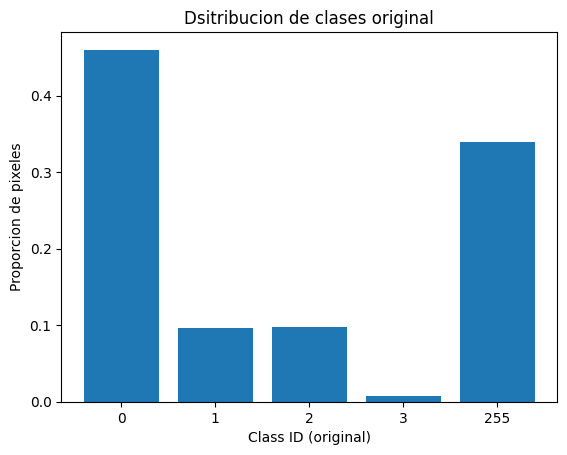

In [20]:
plt.figure()
plt.bar([str(c) for c in classes], fractions)
plt.xlabel("Class ID (original)")
plt.ylabel("Proporcion de pixeles")
plt.title("Dsitribucion de clases original")
plt.show()

Podemos observar que existe un desbalanceo severo en las clases, con 255 dominando y la clase 3 siendo muy baja en general

## Construccion del dataset mejorado

Podemos observar que las 3 misiones tienen diferentes dimensiones y existe un desbalance severo a la hora de trabajar con las clases, entonces se realizara un nuevo dataset que combine todas las 3 misiones enun dataset global para utilizarse en el modelado.

Debido a lo analizado antes se realiza un remapeo semantico asi como una normalizacion de algunos nombres para tener un analisis mas completo a la hora de trabajar con las imagenes

Se realiza la normalizacion de algunos nombres en imagenes de M2020 

In [21]:
def normalize_m2020_name(name):
    name = name.replace("_0LLJ", "")
    name = name.replace("_merged1", "")
    name = name.replace("_merged2", "")
    name = name.replace("_merged3", "")
    name = name.replace("_merged4", "")
    name = name.replace("_merged5", "")
    name = name.replace("_merged6", "")
    name = name.replace("_merged7", "")
    name = name.replace("_merged8", "")
    name = name.replace("_merged9", "")
    name = name.replace("_merged16", "")
    return name

images = {normalize_m2020_name(os.path.splitext(f)[0])
          for f in os.listdir(m2020_ncam_images)
          if f.lower().endswith((".jpg",".jpeg"))}

labels = {normalize_m2020_name(os.path.splitext(f)[0])
          for f in os.listdir(m2020_nav_labels)
          if f.lower().endswith(".png")}

print("Total normalized images:", len(images))
print("Total normalized labels:", len(labels))

print("Images without label:", len(images - labels))
print("Labels without image:", len(labels - images))

Total normalized images: 4286
Total normalized labels: 3827
Images without label: 3813
Labels without image: 3354


In [22]:
valid_pairs = images.intersection(labels)
print("Valid pairs:", len(valid_pairs))

Valid pairs: 473


Se realiza una configuracion en el msl para las labels de este rover 

In [23]:
# ================================
# CONFIGURACIÓN CORRECTA MSL NCAM
# ================================

import os
import numpy as np
from PIL import Image
import random

base_path = r"C:\Users\Hp\Documents\Deep learning\Entregable1\docs"

msl_ncam_labels = os.path.join(
    base_path,
    "msl",
    "ncam",
    "labels",
    "train"
)

print("Ruta:", msl_ncam_labels)
print("Total máscaras:", len(os.listdir(msl_ncam_labels)))


# ================================
# FUNCIÓN DE ANÁLISIS
# ================================

def analyze_mask_distribution(label_folder, sample_size=50):
    files = [f for f in os.listdir(label_folder) if f.endswith(".png")]
    sampled = random.sample(files, min(sample_size, len(files)))
    
    class_counts = {}
    total_pixels = 0
    
    for file in sampled:
        mask = np.array(Image.open(os.path.join(label_folder, file)))
        unique, counts = np.unique(mask, return_counts=True)
        
        for u, c in zip(unique, counts):
            class_counts[u] = class_counts.get(u, 0) + c
            total_pixels += c
            
    return class_counts, total_pixels


class_counts, total_pixels = analyze_mask_distribution(msl_ncam_labels)

print("\nDistribución aproximada de clases (50 máscaras):")

for k in sorted(class_counts.keys()):
    print(f"Clase {k}: {class_counts[k] / total_pixels:.4f}")

Ruta: C:\Users\Hp\Documents\Deep learning\Entregable1\docs\msl\ncam\labels\train
Total máscaras: 16064

Distribución aproximada de clases (50 máscaras):
Clase 0: 0.2199
Clase 1: 0.3088
Clase 2: 0.0396
Clase 3: 0.0019
Clase 255: 0.4297


Se realiza un mapeo unificado de las clases del dataset

In [24]:
import json
import os

base_path = r"C:\Users\Hp\Documents\Deep learning\Entregable1\docs"

label_keys_path = os.path.join(base_path, "label_keys.json")

with open(label_keys_path, "r") as f:
    label_keys = json.load(f)

print(label_keys)

{'NAV': {'0': 'soil', '1': 'bedrock', '2': 'sand', '3': 'big rock', '255': None}, 'M2020_GEO': {'0': 'bedrock_massive', '1': 'bedrock_layered (angled)', '2': 'bedrock_layered (flat)', '3': 'bedrock_layered (unsure)', '4': 'bedrock_conglomerate', '5': 'bedrock_holey', '6': 'bedrock_unsure', '10': 'float rock(s)_massive', '11': 'float rock(s)_layered (angled)', '12': 'float rock(s)_layered (flat)', '13': 'float rock(s)_layered (unsure)', '14': 'float rock(s)_conglomerate', '15': 'float rock(s)_holey', '16': 'float rock(s)_mixed', '17': 'float rock(s)_unsure', '20': 'sand_dune', '21': 'sand_ripples', '22': 'sand_sand', '30': 'pebbles', '40': 'vein (rare)', '50': 'hill/peak', '255': None}}


In [25]:
geo_to_nav_mapping = {
    # Bedrock
    0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1,
    40: 1,

    # Float rocks → big rock
    10: 3, 11: 3, 12: 3, 13: 3, 14: 3, 15: 3, 16: 3, 17: 3,

    # Sand
    20: 2, 21: 2, 22: 2,

    # Soil
    30: 0,
    50: 0,

    # Ignore
    255: 255
}

print("Mapping creado correctamente.")

Mapping creado correctamente.


In [26]:
import os
import numpy as np
from PIL import Image
import random

base_path = r"C:\Users\Hp\Documents\Deep learning\Entregable1\docs"

geo_labels_path = os.path.join(
    base_path,
    "m2020",
    "labels",
    "M2020_GEO",
    "ncam"
)

# Tomar una máscara aleatoria
sample_mask_name = random.choice(os.listdir(geo_labels_path))
sample_mask_path = os.path.join(geo_labels_path, sample_mask_name)

mask = np.array(Image.open(sample_mask_path))

print("Máscara analizada:", sample_mask_name)

# Clases originales
original_classes = np.unique(mask)
print("Clases originales:", original_classes)

# Aplicar mapping
remapped_mask = np.copy(mask)
unmapped_values = []

for val in original_classes:
    if val in geo_to_nav_mapping:
        remapped_mask[mask == val] = geo_to_nav_mapping[val]
    else:
        unmapped_values.append(val)

print("Clases remapeadas:", np.unique(remapped_mask))

if unmapped_values:
    print("⚠️ Clases sin mapping:", unmapped_values)
else:
    print("✅ Todas las clases están correctamente mapeadas.")

Máscara analizada: NLF_0044_0670851758_649EBY_N0031416NCAM00602_00_0LLJ_merged3.png
Clases originales: [  2  16  21  22  30 255]
Clases remapeadas: [  0   1   2   3 255]
✅ Todas las clases están correctamente mapeadas.


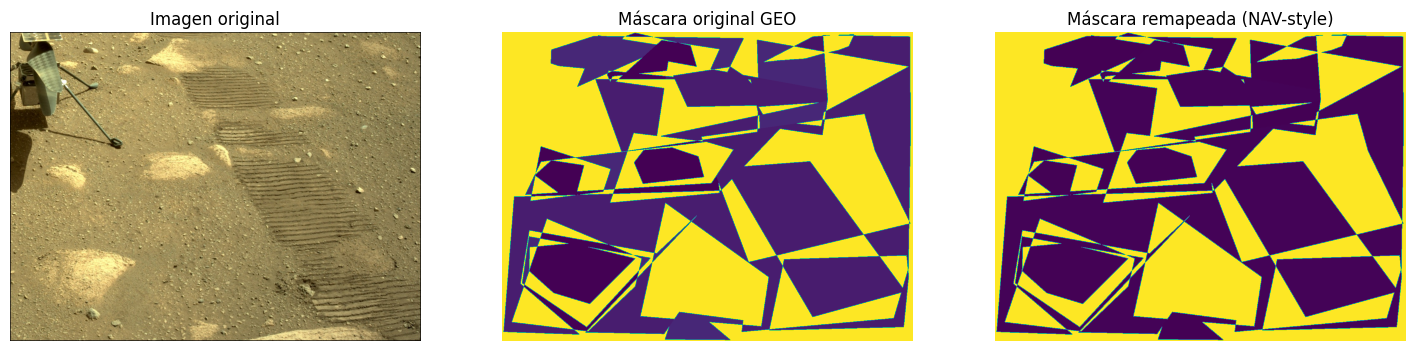

In [27]:
import matplotlib.pyplot as plt

# Extraer nombre base para buscar imagen
image_name = sample_mask_name.split("_merged")[0] + ".jpeg"

image_path = os.path.join(
    base_path,
    "m2020",
    "images",
    "ncam",
    image_name
)

image = np.array(Image.open(image_path))

# Visualización
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask)
plt.title("Máscara original GEO")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(remapped_mask)
plt.title("Máscara remapeada (NAV-style)")
plt.axis("off")

plt.show()

Podemos observar que el mapeo de clases fue realizado correctamente para las imagenes con clases GEO, de esta manera tenemos mascaras unificadas para las imagenes de los 3 rovers

In [71]:
label_files = [f for f in os.listdir(geo_labels_path) if f.endswith(".png")]
sampled_files = random.sample(label_files, min(100, len(label_files)))

pixel_counter = Counter()
total_pixels = 0

for fname in sampled_files:
    mask = np.array(Image.open(os.path.join(geo_labels_path, fname)))

    remapped_mask = np.full_like(mask, fill_value=255)
    for orig_val, new_val in geo_to_nav_mapping.items():
        remapped_mask[mask == orig_val] = new_val

    unique, counts = np.unique(remapped_mask, return_counts=True)
    for u, c in zip(unique, counts):
        pixel_counter[int(u)] += int(c)
        total_pixels += int(c)

class_distribution = {
    cls: count / total_pixels
    for cls, count in pixel_counter.items()
}

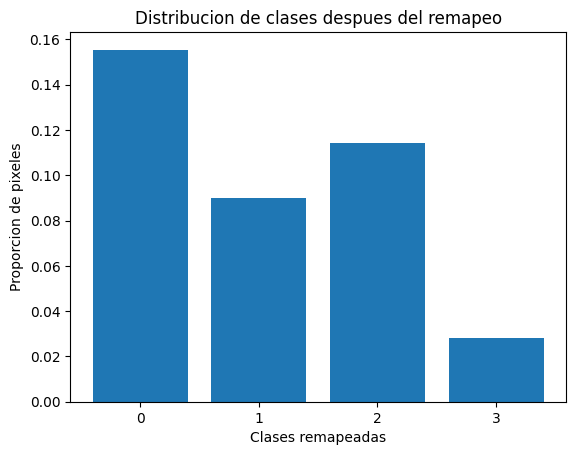

In [72]:
IGNORE_INDEX=255
classes = sorted(c for c in class_distribution if c != IGNORE_INDEX)
fractions = [class_distribution[c] for c in classes]

plt.figure()
plt.bar([str(c) for c in classes], fractions)
plt.xlabel("Clases remapeadas")
plt.ylabel("Proporcion de pixeles")
plt.title("Distribucion de clases despues del remapeo")
plt.show()

Podemos observar que despues de realizar el remapeado no se crearon clases fantasma y las clases estan mas balanceadas entre si 

Revisamos y contamos la distribucion de pixeles por clase 

In [30]:
from collections import Counter
import tqdm

class_counter = Counter()

for file in os.listdir(geo_labels_path):
    mask = np.array(Image.open(os.path.join(geo_labels_path, file)))
    
    for val in np.unique(mask):
        if val in geo_to_nav_mapping:
            mapped_val = geo_to_nav_mapping[val]
            class_counter[mapped_val] += np.sum(mask == val)

print("Distribución de píxeles remapeados:")
for k in sorted(class_counter.keys()):
    print(f"Clase {k}: {class_counter[k]}")

Distribución de píxeles remapeados:
Clase 0: 466491714
Clase 1: 224739495
Clase 2: 292036473
Clase 3: 67379228
Clase 255: 1500571442


In [31]:
nav_labels_path = os.path.join(
    base_path,
    "m2020",
    "labels",
    "NAV"
)

from collections import Counter

nav_counter = Counter()

for file in os.listdir(nav_labels_path):
    mask = np.array(Image.open(os.path.join(nav_labels_path, file)))
    
    for val in np.unique(mask):
        nav_counter[val] += np.sum(mask == val)

print("Distribución NAV:")
for k in sorted(nav_counter.keys()):
    print(f"Clase {k}: {nav_counter[k]}")

Distribución NAV:
Clase 0: 1517146505
Clase 1: 630772689
Clase 2: 469519802
Clase 3: 71059788
Clase 255: 1537560480


In [32]:
from collections import Counter
import os
import numpy as np
from PIL import Image

msl_labels_path = r"C:\Users\Hp\Documents\Deep learning\Entregable1\docs\msl\ncam\labels\train"

msl_counter = Counter()

for file in os.listdir(msl_labels_path):
    mask = np.array(Image.open(os.path.join(msl_labels_path, file)))
    for val in np.unique(mask):
        msl_counter[val] += np.sum(mask == val,dtype=np.int64)

print("Distribución MSL:")
for k in sorted(msl_counter.keys()):
    print(f"Clase {k}: {msl_counter[k]}")

Distribución MSL:
Clase 0: 3485135841
Clase 1: 4660855168
Clase 2: 1126246813
Clase 3: 86225600
Clase 255: 7485861442


In [33]:
mer_labels_path = r"C:\Users\Hp\Documents\Deep learning\Entregable1\docs\mer\labels\train\merged-unmasked"

mer_counter = Counter()

for file in os.listdir(mer_labels_path):
    mask = np.array(Image.open(os.path.join(mer_labels_path, file)))
    for val in np.unique(mask):
        mer_counter[val] += np.sum(mask == val,dtype=np.int64)

print("Distribución MER:")
for k in sorted(mer_counter.keys()):
    print(f"Clase {k}: {mer_counter[k]}")

Distribución MER:
Clase 0: 2012496282
Clase 1: 1038559262
Clase 2: 1680433533
Clase 3: 34180514
Clase 255: 4154566441


Construimos los pares de imagenes con sus labels

In [36]:
import os

base_path = r"C:\Users\Hp\Documents\Deep learning\Entregable1\docs"

def build_pairs_fast(image_dir, mask_dir):
    pairs = []
    
    image_files = os.listdir(image_dir)
    mask_files = [m for m in os.listdir(mask_dir) if m.endswith(".png")]
    
    for img_name in image_files:
        base_name = os.path.splitext(img_name)[0]
        img_path = os.path.join(image_dir, img_name)
        
        # Buscar máscara que empiece con el nombre base
        for mask_name in mask_files:
            if mask_name.startswith(base_name):
                mask_path = os.path.join(mask_dir, mask_name)
                pairs.append((img_path, mask_path))
                break
    
    return pairs


# ==========================
# ==== MSL =================
# ==========================

msl_mcam_img = os.path.join(base_path, "msl", "mcam", "images")
msl_mcam_lbl = os.path.join(base_path, "msl", "mcam", "labels", "train")

msl_ncam_img = os.path.join(base_path, "msl", "ncam", "images", "edr")
msl_ncam_lbl = os.path.join(base_path, "msl", "ncam", "labels", "train")

msl_paths = []
msl_paths += build_pairs_fast(msl_mcam_img, msl_mcam_lbl)
msl_paths += build_pairs_fast(msl_ncam_img, msl_ncam_lbl)


# ==========================
# ==== MER =================
# ==========================

mer_img = os.path.join(base_path, "mer", "images", "eff")
mer_lbl = os.path.join(base_path, "mer", "labels", "train", "merged-unmasked")

mer_paths = build_pairs_fast(mer_img, mer_lbl)


# ==========================
# ==== NAV (M2020) ========
# ==========================

nav_img = os.path.join(base_path, "m2020", "images", "ncam")
nav_lbl = os.path.join(base_path, "m2020", "labels", "NAV")

nav_paths = build_pairs_fast(nav_img, nav_lbl)


print("MSL:", len(msl_paths))
print("MER:", len(mer_paths))
print("NAV:", len(nav_paths))

MSL: 25163
MER: 8303
NAV: 2642


Creamos el dataset final que se utilizara en el modelado

In [37]:
import random
from torch.utils.data import Dataset
from PIL import Image
import torch
import os

class MarsBalancedDataset(Dataset):
    def __init__(self, msl_paths, mer_paths, nav_paths, transform=None, length=30000):
        self.msl_paths = msl_paths
        self.mer_paths = mer_paths
        self.nav_paths = nav_paths
        self.transform = transform
        
        # longitud artificial para entrenamiento
        self.length = length
        
        self.rovers = ["MSL", "MER", "NAV"]

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        
        # Elegir rover aleatorio (balance uniforme)
        rover = random.choice(self.rovers)
        
        if rover == "MSL":
            img_path, mask_path = random.choice(self.msl_paths)
        elif rover == "MER":
            img_path, mask_path = random.choice(self.mer_paths)
        else:
            img_path, mask_path = random.choice(self.nav_paths)
        
        # Cargar imagen y máscara
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)
        
        if self.transform:
            image = self.transform(image)
        
        mask = torch.from_numpy(
            torch.ByteTensor(torch.ByteStorage.from_buffer(mask.tobytes()))
        ).reshape(mask.size[1], mask.size[0]).long()
        
        return image, mask

In [38]:
dataset = MarsBalancedDataset(msl_paths, mer_paths, nav_paths, length=30000)

print(len(dataset))

30000
